<a href="https://colab.research.google.com/github/erjank/mupt-analysis/blob/main/MSD_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Example MSD calculation upon a coarse-grained (N=60; C=1000) trajectory output. Trajectory has 21 frames which are non-linearly dumped with respect to the timesteps. Timesteps for a particular frame can be seen in the `python _non_linear.txt` file..

#### import the files
#### 1) .dump (contains trajectories)
#### 2) .txt (containes timesteps)

In [ ]:
# Get dependencies that aren't included in colab, plus example files for analysis
!pip install MDAnalysis
!wget https://raw.githubusercontent.com/MuPT-hub/mupt-analysis/refs/heads/main/production_1ns.dump # TODO: update these according to filenames if needed by Colab
!wget https://raw.githubusercontent.com/MuPT-hub/mupt-analysis/refs/heads/main/python.txt # TODO: not needed anymore: non-linear calculation is part of MDAnalysis 2.10.0 now

--2025-06-11 18:06:11--  https://raw.githubusercontent.com/MuPT-hub/mupt-analysis/refs/heads/main/python.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 115 [text/plain]
Saving to: ‘python.txt’

python.txt          100%[===================>]     115  --.-KB/s    in 0s      

2025-06-11 18:06:11 (6.06 MB/s) - ‘python.txt’ saved [115/115]



# MSD including every bead (atom)

In [1]:
import MDAnalysis as mda
import matplotlib.pyplot as plt
import numpy as np
import MDAnalysis.analysis.msd as msd
import MDAnalysis.transformations.nojump as nj

u_nj = mda.Universe("CG_1ns_non_linear_N_60K.dump", format="LAMMPSDUMP")
transformation = nj.NoJump()
u_nj.trajectory.add_transformations(transformation)
MSD = msd.EinsteinMSD(u_nj, select='all', msd_type='xyz', fft=False, non_linear=True) # non_linear = True; as the frames of the dump are non-linearly spaced
MSD.run()
y_MDA_nj = MSD.results.timeseries
x_MDA_nj = MSD.results.delta_t_values

/opt/homebrew/Caskroom/miniforge/base/envs/mda-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ganguly.sirsha/Documents/MDAnalysis_PR/mdanalysis/package/MDAnalysis/topology/LAMMPSParser.py:670: UserWarning: Guessed all Masses to 1.0
  warnings.warn("Guessed all Masses to 1.0")
/Users/ganguly.sirsha/Documents/MDAnalysis_PR/mdanalysis/package/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


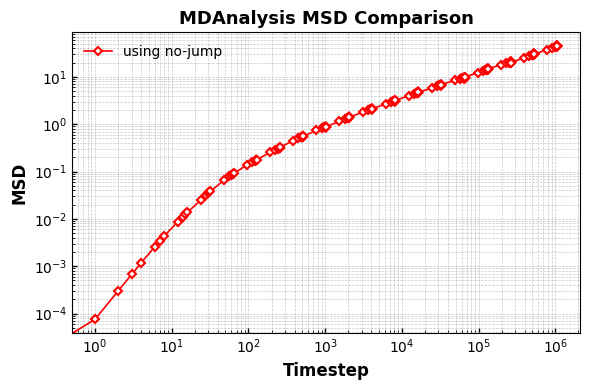

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.loglog(
    x_MDA_nj, y_MDA_nj,
    marker='D',                # Diamond marker
    markersize=4,
    markerfacecolor='white',
    markeredgecolor='red',
    markeredgewidth=1.5,
    linestyle='-',              # Solid line
    color='red',
    linewidth=1.2,
    label='using no-jump'
)

# Labels and title with font customization
plt.xlabel('Timestep', fontsize=12, fontweight='bold', fontfamily='sans-serif')
plt.ylabel('MSD', fontsize=12, fontweight='bold', fontfamily='sans-serif')
plt.title('MDAnalysis MSD Comparison', fontsize=13, fontweight='bold', fontfamily='sans-serif')

# Legend
plt.legend(fontsize=10, frameon=False)

# Grid and layout
plt.grid(True, which='both', ls='--', lw=0.5, alpha=0.7)

# Ticks
plt.tick_params(axis='both', which='major', labelsize=10, width=1, direction='in')
plt.tick_params(axis='both', which='minor', direction='in')

plt.tight_layout()
plt.show()

# particle speific MSD

In [17]:
y_MDA_nj_by_particle = MSD.results.msds_by_particle[:,10] # time averaged msd for the 11th particle

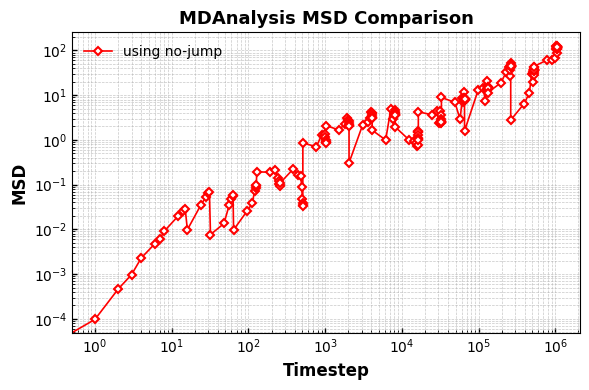

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.loglog(
    x_MDA_nj, y_MDA_nj_by_particle,
    marker='D',                # Diamond marker
    markersize=4,
    markerfacecolor='white',
    markeredgecolor='red',
    markeredgewidth=1.5,
    linestyle='-',              # Solid line
    color='red',
    linewidth=1.2,
    label='using no-jump'
)

# Labels and title with font customization
plt.xlabel('Timestep', fontsize=12, fontweight='bold', fontfamily='sans-serif')
plt.ylabel('MSD', fontsize=12, fontweight='bold', fontfamily='sans-serif')
plt.title('MDAnalysis MSD Comparison', fontsize=13, fontweight='bold', fontfamily='sans-serif')

# Legend
plt.legend(fontsize=10, frameon=False)

# Grid and layout
plt.grid(True, which='both', ls='--', lw=0.5, alpha=0.7)

# Ticks
plt.tick_params(axis='both', which='major', labelsize=10, width=1, direction='in')
plt.tick_params(axis='both', which='minor', direction='in')

plt.tight_layout()
plt.show()

comments:

`NoJump` transformation is applied on the universe first for correct unwrapping of the coordinates in the dump following LAMMPS PBC flags (ix iy iz). If a pre-unwrapped trajectory dump is used then it's not needed.

`non_linear=True` can only be use with `fft=False`. So, if the dump is linear, DO `non_linear=False` (also the default case). Current example of non-linear trajectory dump is more general thus has been included as the reference.